In [ ]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
# from stfe.gene_utils import get_markers
import scanpy as sc
from plotly3d.plot import trajectories
from sklearn.cluster import KMeans
import pandas as pd
import pathlib
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [41]:
import scanpy as sc
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
PROCESSED_DATA_DIR = os.path.join('../../data', 'processed')
DIMENSION_CHANGER_DIR = os.path.join('../../dimension_changer')
RESULTS_DIR = os.path.join('../../results')
REPORTS_DIR = os.path.join('../../reports/figures')

data_name = 'scRNAseq'
SAVE_PATH = os.path.join(RESULTS_DIR, data_name)

adata = sc.read(os.path.join(PROCESSED_DATA_DIR, 'adata_mioflow.h5ad'))
gene_names = adata.var_names

traj = np.load(os.path.join(SAVE_PATH,'trajectories_gene_space.npy'))

In [22]:

traj_mean = traj.mean(axis=1)
traj_std = traj.std(axis=1)
traj_mean_std = traj_mean.std(axis=0)
zero_std_genes = traj_mean_std == 0
gene_names = np.array(gene_names)[~zero_std_genes]
traj, traj_mean, traj_std, traj_mean_std = traj[..., ~zero_std_genes], traj_mean[..., ~zero_std_genes], traj_std[..., ~zero_std_genes], traj_mean_std[..., ~zero_std_genes]
# traj_mean_normalized = (traj_mean - traj_mean.mean(axis=0)) / traj_mean.std(axis=0)
traj_mean_normalized = (traj_mean - traj_mean.min(axis=0)) / (traj_mean.max(axis=0) - traj_mean.min(axis=0))

trends_df = pd.DataFrame(traj_mean_normalized, columns=gene_names, index=[f't{i}' for i in range(traj_mean_normalized.shape[0])]).T
# Get the indices of top 5 values for each row
top_5_indices = trends_df.apply(lambda x: np.where(x >= sorted(x)[-1])[0].mean(), axis=1)
# Sort the dataframe by mean of top 5 indices
trends_df_sorted = trends_df.iloc[top_5_indices.argsort()]

trends_df_sorted_numerical_index = trends_df_sorted.reset_index(drop=True)

# # Split indices into 5 groups using the cluster points
# cluster_pts = [816, 1740, 3120, 4032]
# cluster_groups = [
#     trends_df_sorted.index[:cluster_pts[0]].tolist(),
#     trends_df_sorted.index[cluster_pts[0]:cluster_pts[1]].tolist(),
#     trends_df_sorted.index[cluster_pts[1]:cluster_pts[2]].tolist(), 
#     trends_df_sorted.index[cluster_pts[2]:cluster_pts[3]].tolist(),
#     trends_df_sorted.index[cluster_pts[3]:].tolist()
# ]

# cluster_df = pd.DataFrame(np.arange(len(trends_df_sorted.index)), index=trends_df_sorted.index, columns=['number'])
# cluster_df['cluster'] = np.nan
# for i, cluster_group in enumerate(cluster_groups):
#     cluster_df.loc[cluster_group, 'cluster'] = i



In [42]:
top_5_indices

A1BG (ENSG00000121410)        99.0
A1BG-AS1 (ENSG00000268895)    99.0
A2M (ENSG00000175899)         99.0
A2M-AS1 (ENSG00000245105)     99.0
A2ML1 (ENSG00000166535)        0.0
                              ... 
ZYG11A (ENSG00000203995)       0.0
ZYG11B (ENSG00000162378)       0.0
ZYX (ENSG00000159840)          0.0
ZZEF1 (ENSG00000074755)       66.0
ZZZ3 (ENSG00000036549)        14.0
Length: 18019, dtype: float64

In [23]:
# placeholders
cluster_pts = None
cluster_groups = None
cluster_df = None

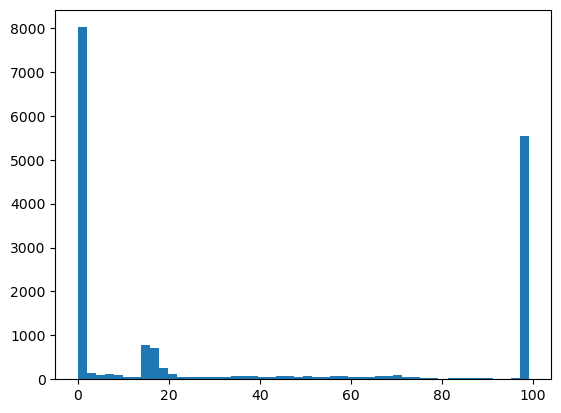

In [24]:
plt.hist(top_5_indices.values, 50);

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks, argrelmin
from scipy.optimize import minimize_scalar
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity
import warnings


def find_thresholds_kde(data, bandwidth='scott', method='scipy', num_points=1000):
    """
    Find mode thresholds using Kernel Density Estimation.
    
    Parameters:
    -----------
    data : array-like
        1D array of data points
    bandwidth : float or str, default='scott'
        Bandwidth for KDE. Can be 'scott', 'silverman', or a float value
    method : str, default='scipy'
        Method to use: 'scipy' or 'sklearn'
    num_points : int, default=1000
        Number of points to evaluate density on
        
    Returns:
    --------
    thresholds : array
        Array of threshold values (local minima of density)
    density_x : array
        X values where density was evaluated
    density_y : array
        Density values
    """
    data = np.asarray(data).flatten()
    
    # Create evaluation grid
    x_min, x_max = data.min(), data.max()
    margin = (x_max - x_min) * 0.1  # Add 10% margin
    x_eval = np.linspace(x_min - margin, x_max + margin, num_points)
    
    if method == 'scipy':
        # Use scipy's gaussian_kde
        if bandwidth == 'scott':
            kde = stats.gaussian_kde(data)
        elif bandwidth == 'silverman':
            kde = stats.gaussian_kde(data, bw_method='silverman')
        else:
            kde = stats.gaussian_kde(data, bw_method=bandwidth)
        
        density = kde(x_eval)
        
    elif method == 'sklearn':
        # Use sklearn's KernelDensity
        if bandwidth == 'scott':
            # Scott's rule: n^(-1/(d+4)) where d=1 for 1D
            bw = len(data) ** (-1.0/5.0) * data.std()
        elif bandwidth == 'silverman':
            # Silverman's rule
            bw = (len(data) * 3.0/4.0) ** (-1.0/5.0) * data.std()
        else:
            bw = bandwidth
            
        kde = KernelDensity(bandwidth=bw, kernel='gaussian')
        kde.fit(data.reshape(-1, 1))
        log_density = kde.score_samples(x_eval.reshape(-1, 1))
        density = np.exp(log_density)
    
    else:
        raise ValueError("method must be 'scipy' or 'sklearn'")
    
    # Find local minima
    # We use argrelmin to find local minima
    min_indices = argrelmin(density, order=5)[0]  # order=5 for noise robustness
    
    # Filter minima that are too close to boundaries
    boundary_margin = int(num_points * 0.05)  # 5% margin
    min_indices = min_indices[
        (min_indices > boundary_margin) & 
        (min_indices < num_points - boundary_margin)
    ]
    
    thresholds = x_eval[min_indices]
    
    # Filter thresholds to be within data range
    thresholds = thresholds[(thresholds >= data.min()) & (thresholds <= data.max())]
    
    return thresholds, x_eval, density


In [50]:
thresholds, x_eval, density = find_thresholds_kde(top_5_indices.values, bandwidth=0.1, num_points=1000)

In [51]:
thresholds

array([11.14864865, 31.6027027 , 41.59189189, 62.64054054, 82.02432432])

In [104]:
def plot_results(data, thresholds, density_x, density_y):
    """
    Plot the results of both methods for comparison.
    
    Parameters:
    -----------
    data : array-like
        Original data
    thresholds : array
        Thresholds from KDE method
    """
    fig, ax = plt.subplots(1, 1, figsize=(5, 2))
    
    # Plot 1: KDE results
    ax.hist(data, bins=50, density=True, alpha=0.7, color='lightblue', label='Data histogram')
    ax.plot(density_x, density_y, 'b-', linewidth=2, label='KDE')
    
    for thresh in thresholds:
        ax.axvline(thresh, color='red', linestyle='--', alpha=0.8, label='KDE threshold' if thresh == thresholds[0] else "")
    
    ax.set_title('Kernel Density Estimation Method')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    

    # sns.heatmap(traj, cbar=True)  # or plt.imshow(traj) if using imshow
    plt.axis('off')               # Remove axes
    plt.grid(False)               # Remove grid lines
    plt.xlabel('')                # Remove x label
    plt.ylabel('')                # Remove y label
    # plt.title('')                 # Remove title
    # plt.show()

    # Remove legend if it exists
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    plt.tight_layout()
    plt.show()

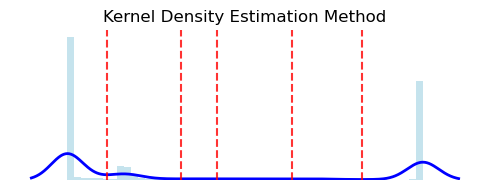

In [105]:
plot_results(top_5_indices.values, thresholds, x_eval, density)

In [54]:
top_5_indices.values

array([99., 99., 99., ...,  0., 66., 14.])

In [55]:
thresholds

array([11.14864865, 31.6027027 , 41.59189189, 62.64054054, 82.02432432])

In [56]:
# Find the indices in top_5_indices where the value is greater than each threshold
cluster_pts = [np.searchsorted(sorted(top_5_indices.values), t, side='right') for t in thresholds]

In [57]:
top_5_indices

A1BG (ENSG00000121410)        99.0
A1BG-AS1 (ENSG00000268895)    99.0
A2M (ENSG00000175899)         99.0
A2M-AS1 (ENSG00000245105)     99.0
A2ML1 (ENSG00000166535)        0.0
                              ... 
ZYG11A (ENSG00000203995)       0.0
ZYG11B (ENSG00000162378)       0.0
ZYX (ENSG00000159840)          0.0
ZZEF1 (ENSG00000074755)       66.0
ZZZ3 (ENSG00000036549)        14.0
Length: 18019, dtype: float64

In [58]:
cluster_pts

[8547, 10785, 11116, 11801, 12303]

In [59]:
cluster_pts

[8547, 10785, 11116, 11801, 12303]

/var/folders/1r/l8_zwkvx7_g7b632hf_1517c0000gn/T/ipykernel_28019/6540212.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


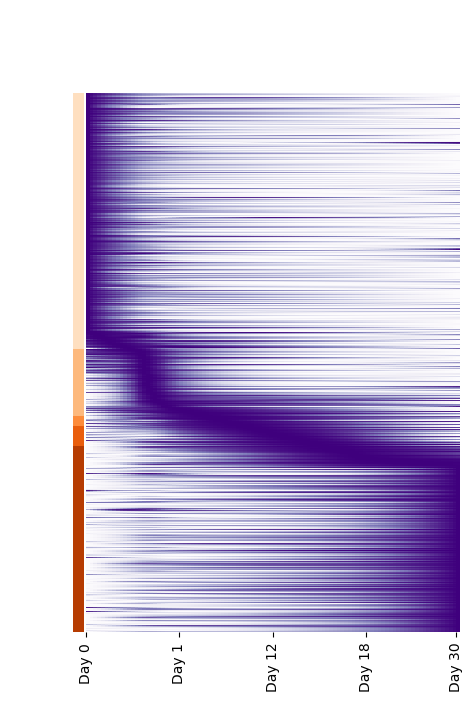

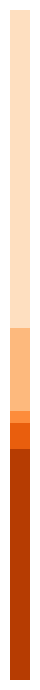

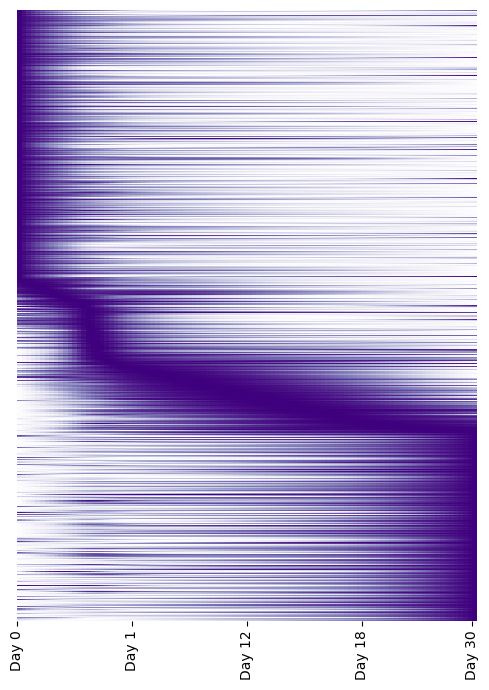

In [60]:
cluster_groups = [
    trends_df_sorted.index[:cluster_pts[0]].tolist(),
    trends_df_sorted.index[cluster_pts[0]:cluster_pts[1]].tolist(),
    trends_df_sorted.index[cluster_pts[1]:cluster_pts[2]].tolist(), 
    # trends_df_sorted.index[cluster_pts[2]:].tolist()
    trends_df_sorted.index[cluster_pts[2]:cluster_pts[3]].tolist(),
    trends_df_sorted.index[cluster_pts[3]:].tolist()
]

cluster_df = pd.DataFrame(np.arange(len(trends_df_sorted.index)), index=trends_df_sorted.index, columns=['number'])
cluster_df['cluster'] = np.nan
for i, cluster_group in enumerate(cluster_groups):
    cluster_df.loc[cluster_group, 'cluster'] = i


# Create a figure with a specific size
fig = plt.figure(figsize=(5, 7))

# Import gridspec from matplotlib
from matplotlib import gridspec
from matplotlib import colors as mcolors

# Create a color palette for the clusters using oranges
cluster_colors = sns.color_palette("Oranges", n_colors=len(cluster_groups))

# Create a gridspec to position the heatmap and color bar - make them closer together
gs = gridspec.GridSpec(1, 2, width_ratios=[0.03, 0.97], wspace=0.01)

# Add an axis for the cluster colors
ax_colors = plt.subplot(gs[0])
# Create a DataFrame with cluster colors as strings instead of tuples
color_map = {i: f'C{i}' for i in range(len(cluster_groups))}
cluster_color_values = cluster_df['cluster'].map(lambda x: color_map[int(x)])
cluster_df_colors = pd.DataFrame({'Cluster': cluster_color_values})

# Create a custom colormap for the clusters using oranges
cluster_cmap = mcolors.ListedColormap([cluster_colors[i] for i in range(len(cluster_groups))])
# Plot the cluster indicators without labels
sns.heatmap(pd.DataFrame(cluster_df['cluster']), cmap=cluster_cmap, 
            cbar=False, ax=ax_colors, yticklabels=False, xticklabels=False)

# Add the main heatmap with purple colormap
ax_heatmap = plt.subplot(gs[1])
sns.heatmap(trends_df_sorted, cmap='Purples', vmin=0, vmax=1,
            cbar=False, ax=ax_heatmap, yticklabels=False)

# Select genes to display on the y-axis
# ytick_genes = ['CD44', 'CAV1', 'EPCAM', 'TWIST1', 'TWIST2', 'SNAI1', 'SNAI2', 'ZEB1', 'ZEB2']
ytick_genes = ['CAV1', 'CDC20', 'FTH1', 'SAT1', 'NPTX2']
ytick_positions = [trends_df_sorted.index.get_loc(gene) for gene in ytick_genes if gene in trends_df_sorted.index]
ytick_labels = [ytick_genes[i] for i, pos in enumerate(ytick_positions)]

# Move y-axis to the right and set ticks
ax_heatmap.yaxis.set_label_position("right")
ax_heatmap.yaxis.tick_right()
ax_heatmap.set_yticks(ytick_positions)
ax_heatmap.set_yticklabels(ytick_labels, fontsize=10)

# Customize x-ticks to show days
days = [0, 1, 12, 18, 30]
tick_positions = [0, 25, 50, 75, 99]  # Evenly spaced positions
ax_heatmap.set_xticks(tick_positions)
ax_heatmap.set_xticklabels([f'Day {d}' for d in days], fontsize=10)

# Add cluster labels to the left
ax_cluster_labels = fig.add_axes([0, 0, 0.02, 1])  # Adjust position as needed
ax_cluster_labels.set_axis_off()

# # Add cluster labels
# for i, cluster_group in enumerate(cluster_groups):
#     # Find the middle position of each cluster
#     start_pos = trends_df_sorted.index.get_loc(cluster_group[0])
#     end_pos = trends_df_sorted.index.get_loc(cluster_group[-1])
#     mid_position = (start_pos + end_pos) / (2 * len(trends_df_sorted))
    
#     # Add text label
#     ax_cluster_labels.text(
#         0.5, 1 - mid_position, f'C{i}', 
#         ha='center', va='center', rotation=90,
#         transform=ax_cluster_labels.transAxes, fontsize=8
#     )

plt.tight_layout()
# plt.savefig(f'{output_dir}/gene_heatmap_cluster.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)
plt.show()
# Save the combined figure
# plt.savefig(f'{output_dir}/gene_heatmap_cluster_combined.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

# Create and save the cluster strip separately - without any labels
fig_strip = plt.figure(figsize=(0.5, 7))
ax_strip = plt.subplot(111)
sns.heatmap(pd.DataFrame(cluster_df['cluster']), cmap=cluster_cmap, 
            cbar=False, ax=ax_strip, yticklabels=False, xticklabels=False)
# No labels for the strip plot
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/gene_heatmap_cluster_strip.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

# Create and save the heatmap separately
fig_heatmap = plt.figure(figsize=(5, 7))
ax_heatmap_only = plt.subplot(111)
sns.heatmap(trends_df_sorted, cmap='Purples', vmin=0, vmax=1,
            cbar=False, ax=ax_heatmap_only, yticklabels=False)
# Set the same y-ticks as the combined figure
ax_heatmap_only.yaxis.set_label_position("right")
ax_heatmap_only.yaxis.tick_right()
ax_heatmap_only.set_yticks(ytick_positions)
ax_heatmap_only.set_yticklabels(ytick_labels, fontsize=10)
# Set the same x-ticks as the combined figure
ax_heatmap_only.set_xticks(tick_positions)
ax_heatmap_only.set_xticklabels([f'Day {d}' for d in days], fontsize=10)
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/gene_heatmap_cluster_heatmap.pdf', bbox_inches='tight', pad_inches=0.1, dpi=300)

In [61]:
cluster_df = pd.DataFrame(np.arange(len(trends_df_sorted.index)), index=trends_df_sorted.index, columns=['number'])
for i, cluster_group in enumerate(cluster_groups):
    cluster_df.loc[cluster_group, 'cluster'] = i
cluster_df

,number,cluster
MRPL37 (ENSG00000116221),0,0.0
GALNT3 (ENSG00000115339),1,0.0
GALNT2 (ENSG00000143641),2,0.0
RBM7 (ENSG00000076053),3,0.0
RBM8A (ENSG00000265241),4,0.0
...,...,...
FAM3A (ENSG00000071889),18014,4.0
RP11-262A16.1 (ENSG00000275322),18015,4.0
FAM3D (ENSG00000198643),18016,4.0
RP11-259K5.2 (ENSG00000270194),18017,4.0


In [62]:
cluster_df.to_csv(f'{REPORTS_DIR}/cluster_df_extreme_T_draft.csv')

In [63]:
cluster_df

,number,cluster
MRPL37 (ENSG00000116221),0,0.0
GALNT3 (ENSG00000115339),1,0.0
GALNT2 (ENSG00000143641),2,0.0
RBM7 (ENSG00000076053),3,0.0
RBM8A (ENSG00000265241),4,0.0
...,...,...
FAM3A (ENSG00000071889),18014,4.0
RP11-262A16.1 (ENSG00000275322),18015,4.0
FAM3D (ENSG00000198643),18016,4.0
RP11-259K5.2 (ENSG00000270194),18017,4.0
